Internship Project - Week 3 & Week 4

End-to-End Sales Forecasting & Demand Intelligence System

**NOTE: The dataset is automatically downloaded from Google Drive using gdown, so no manual upload is required.**

Library and Dataset Loading

In [ ]:
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from prophet import Prophet

In [ ]:
!gdown --id 1CU-8LOd0Rxkm7JpWoHA4vMKVk6HtnLaS # train.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CU-8LOd0Rxkm7JpWoHA4vMKVk6HtnLaS
To: /content/train.csv
100% 2.13M/2.13M [00:00<00:00, 73.5MB/s]


In [ ]:
!gdown --id 10PyyQgWhcm6d0GhcltLtHnU4KrHtJifo #vgsales.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=10PyyQgWhcm6d0GhcltLtHnU4KrHtJifo
To: /content/vgsales.csv
100% 1.36M/1.36M [00:00<00:00, 85.7MB/s]


In [ ]:
sales_df = pd.read_csv('train.csv')
vgsales_df = pd.read_csv('vgsales.csv')

In [ ]:
sales_df.shape

(9800, 18)

In [ ]:
vgsales_df.shape

(16598, 11)

In [ ]:
sales_df.info() # Data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
sales_df.columns # column names

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
sales_df.describe() #summary statistics

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
# Parsing Dates
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"],dayfirst=True,errors="coerce")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"],dayfirst=True,errors="coerce")
# converts the 'Order Date' and 'Ship Date' columns to a datetime format, assuming dates are day/month/year and replacing any unparseable values with NaT (Not a Time) to prevent errors.

In [ ]:
sales_df.dtypes # for verification

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
sales_df["Year"] = sales_df["Order Date"].dt.year

In [ ]:
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

In [ ]:
sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week

In [ ]:
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()

In [ ]:
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [ ]:
# Function for determining season
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(season)

In [ ]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [ ]:
sales_df.isnull().sum() #missing values

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Since Postal Code is not used as an input variable in the forecasting, anomaly detection, or demand segmentation models, these missing values identified in the Postal Code column do not affect the core analytical workflow.

In [ ]:
sales_df.duplicated().sum() # duplicate values

np.int64(0)

In [ ]:
sales_df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
# Aggregating Daily Sales into Weekly and Monthly Totals
sales_df = sales_df.sort_values("Order Date")
sales_df.set_index("Order Date", inplace=True)

In [ ]:
# Weekly Sales
weekly_sales = sales_df["Sales"].resample("W").sum()
weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [ ]:
# Monthly Sales
monthly_sales = sales_df["Sales"].resample("M").sum()
monthly_sales.head()

/tmp/ipykernel_1246/4154904967.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_df["Sales"].resample("M").sum()


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
sales_df.reset_index(inplace=True) # Resetting the index afterward so later operations still have Order Date as a normal column

Product Category with highest total revenue

In [ ]:
category_sales = (sales_df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

In [ ]:
category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


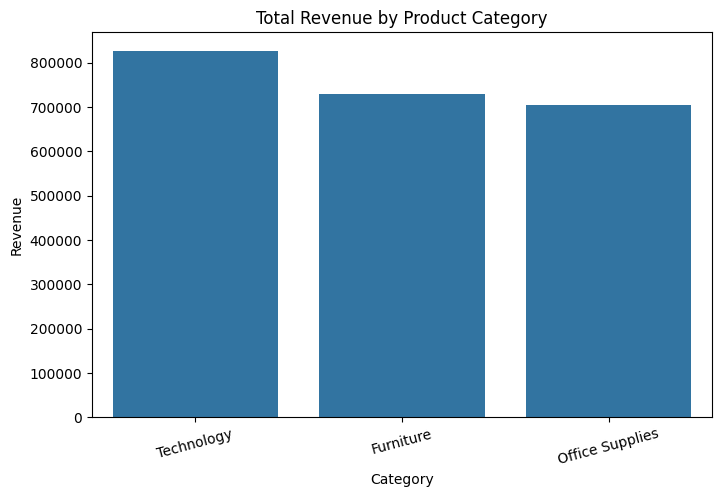

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,y=category_sales.values)
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=15)
plt.show()

Observation: The Technology category generated the highest total revenue, followed by Furniture and Office Supplies. This indicates that technology products contribute the largest share of overall sales.

Region with the most consistent sales growth over 4 years

In [ ]:
region_growth = (sales_df.groupby(["Year", "Region"])["Sales"].sum().reset_index())

In [ ]:
region_growth

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


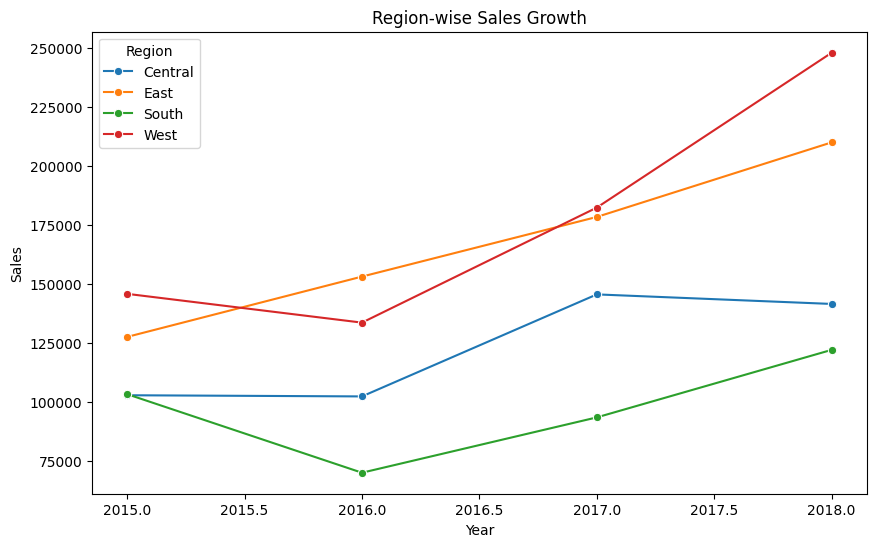

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=region_growth,x="Year",y="Sales",hue="Region",marker="o")
plt.title("Region-wise Sales Growth")
plt.show()

The East region exhibits the most consistent sales growth over the four-year period. Unlike the other regions, the East shows a steady year-over-year increase in sales without any decline. This consistent upward trend suggests stable demand and sustained business performance, making it the most reliable region in terms of sales growth. Although the West region achieved the highest sales by 2018, its decline between 2015 and 2016 indicates less consistent growth compared to the East region.

Average time between Order Date and Ship Date

In [ ]:
sales_df["Shipping Days"] = (sales_df["Ship Date"] -sales_df["Order Date"]).dt.days #adding new column

In [ ]:
sales_df["Shipping Days"].mean() #overall average

np.float64(3.9611224489795918)

In [ ]:
shipping_region = (sales_df.groupby("Region")["Shipping Days"].mean()) # by region

In [ ]:
shipping_region

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


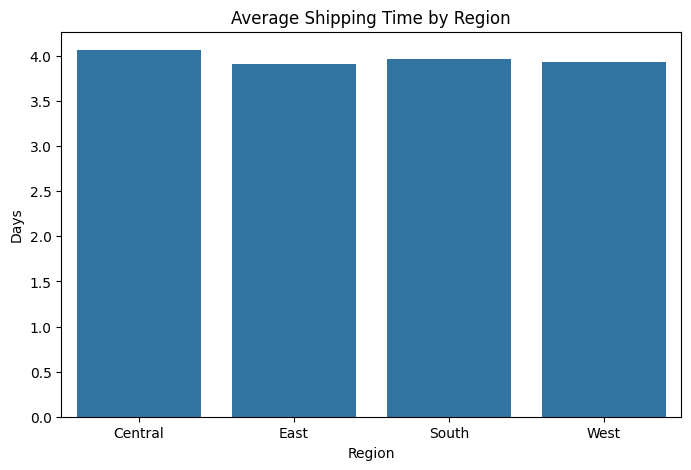

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=shipping_region.index,y=shipping_region.values)
plt.title("Average Shipping Time by Region")
plt.ylabel("Days")
plt.show()

The average shipping time is approximately 4 days across all regions, with only minor differences. The Central region has the highest average shipping time (around 4.1 days), while the East region has the lowest (around 3.9 days). Overall, shipping performance is consistent across all regions, indicating a standardized delivery process with no major regional delays.

Do certain months consistently spike?

In [ ]:
monthly_pattern = (sales_df.groupby("Month Name")["Sales"].mean())

In [ ]:
months = ["January","February","March","April","May","June","July","August","September","October","November","December"]

In [ ]:
monthly_pattern = monthly_pattern.reindex(months)

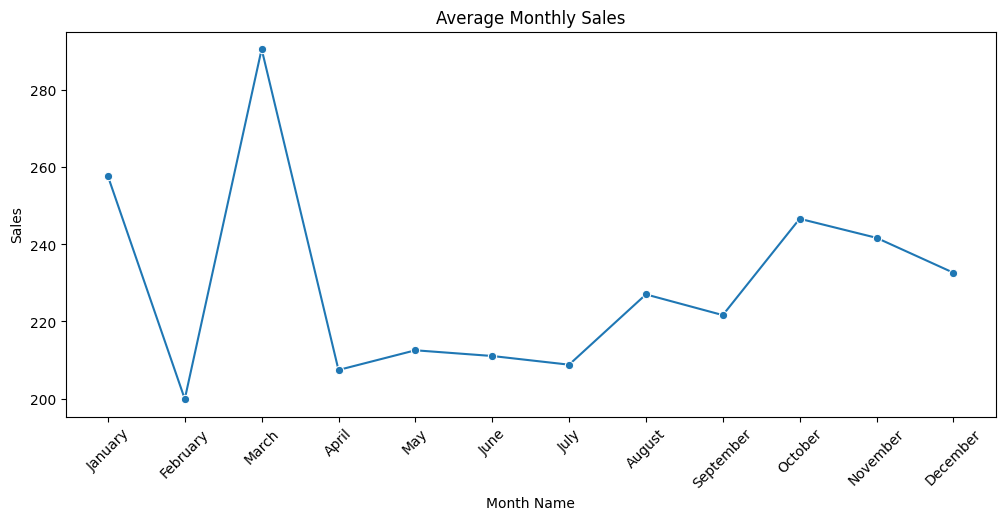

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_pattern.index,y=monthly_pattern.values,marker="o")
plt.xticks(rotation=45)
plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.show()

In [ ]:
monthly_year = (sales_df.groupby(["Year", "Month Name"])["Sales"].sum().reset_index())

In [ ]:
months = ["January","February","March","April","May","June","July","August","September","October","November","December"]

In [ ]:
monthly_year["Month Name"] = pd.Categorical(monthly_year["Month Name"],categories=months,ordered=True)
monthly_year = monthly_year.sort_values(["Year", "Month Name"])

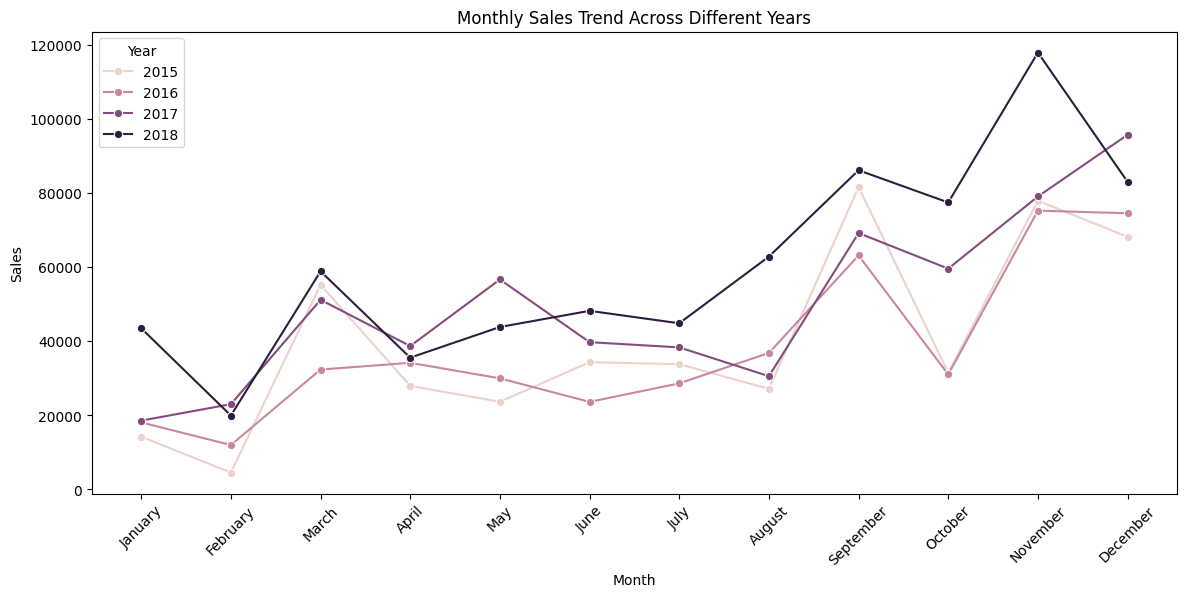

In [ ]:
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_year,x="Month Name",y="Sales",hue="Year",marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend Across Different Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Sales generally increase during the final quarter of the year, particularly in **September, November, and December**.**November** consistently records one of the highest sales values across multiple years, while **December** also maintains strong sales performance.**March** shows a noticeable sales peak in several years, although the magnitude varies.**February** and **April** generally experience lower sales compared to the peak months. Overall, the data suggests that sales are influenced by seasonal demand, with the strongest performance occurring during the last quarter of the year.

**Time Series Analysis & Decomposition**

In [ ]:
monthly_sales = (sales_df.set_index("Order Date")["Sales"].resample("M").sum())
monthly_sales.head()

/tmp/ipykernel_1246/4030585427.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = (sales_df.set_index("Order Date")["Sales"].resample("M").sum())


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


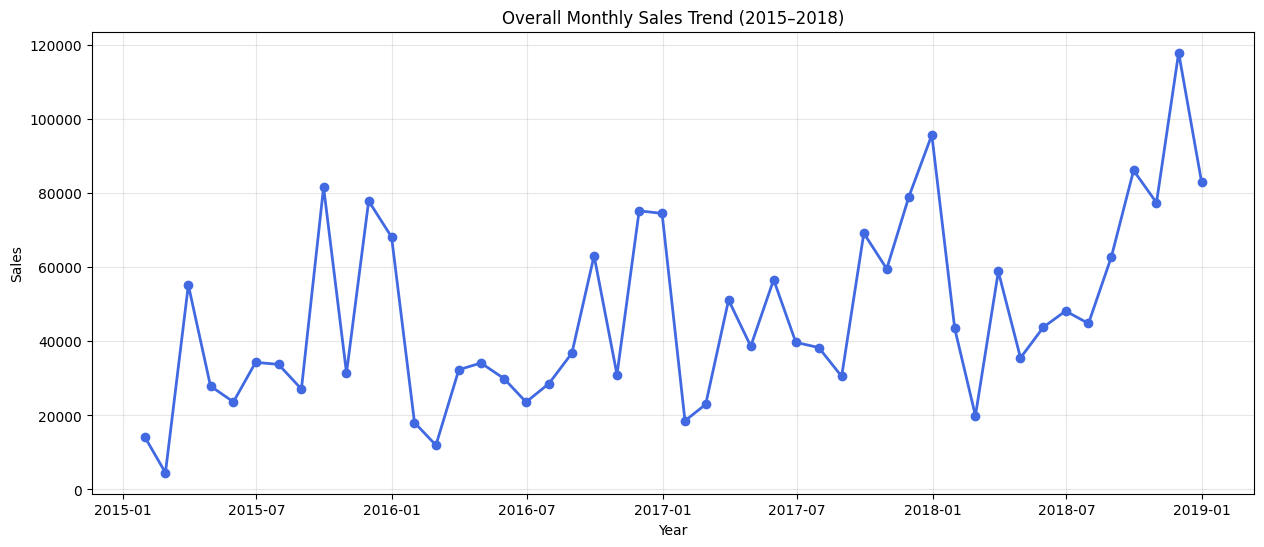

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(monthly_sales,color="royalblue",linewidth=2,marker='o')
plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

The overall monthly sales trend shows a gradual increase from 2015 to 2018. Although monthly sales fluctuate throughout the period, the peak sales values become noticeably higher in the later years, particularly during 2018.
The repeated rise in sales toward the end of each year indicates the presence of seasonality. Sales generally increase during the last quarter of the year before declining again in the following months. This recurring pattern suggests that customer purchasing behavior is influenced by seasonal factors.

In [ ]:
decomposition = seasonal_decompose(monthly_sales,model="additive",period=12) # 12 months = one seasonal cycle

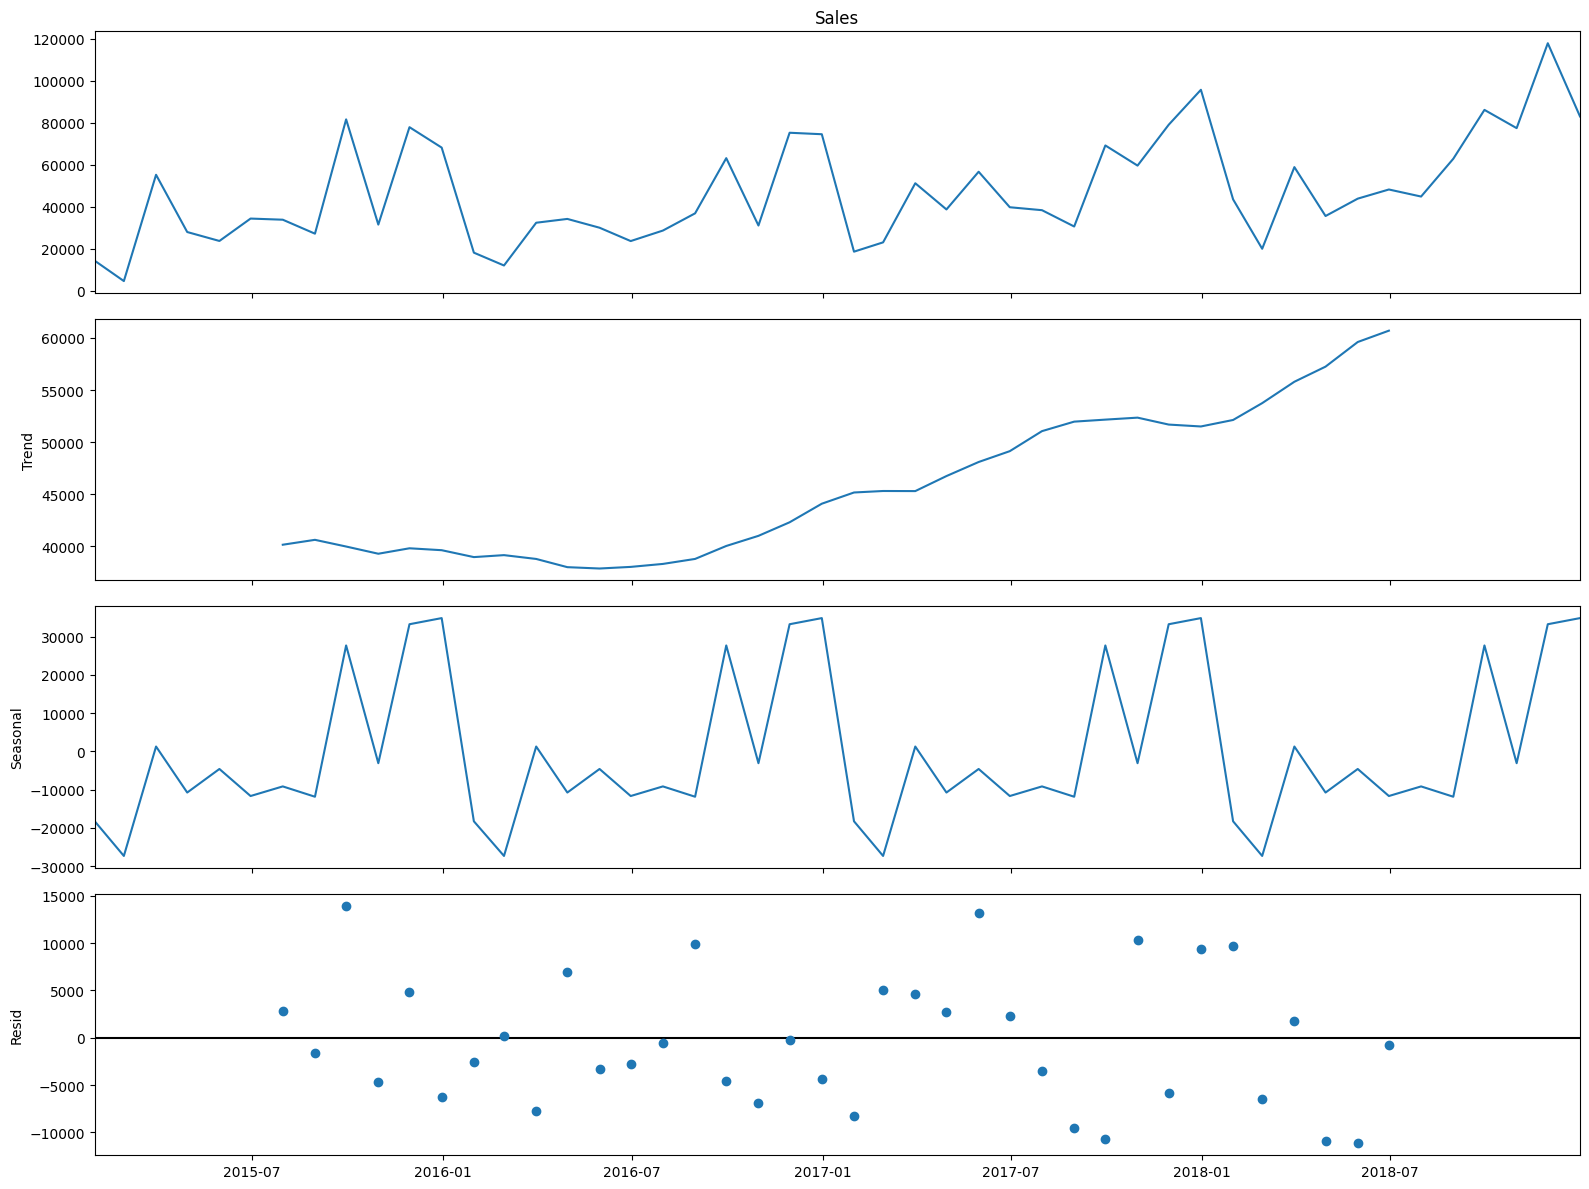

In [ ]:
fig = decomposition.plot()
fig.set_size_inches(16, 12)
plt.tight_layout()
plt.show()

The trend component shows a gradual upward movement over the four-year period.
*  After a slight decline during the early months, the trend steadily increases from 2016 onward, reaching its highest values in 2018. This indicates that the overall sales performance of the business improved over time, reflecting sustained business growth.
* The seasonal component exhibits a clear repeating pattern that recurs approx. every 12 months, suggesting that seasonality has a significant influence on monthly sales and should be considered when forecasting future demand. Positive seasonal values indicate months where sales are consistently above the overall trend, while negative values represent months with below-average sales.
* The residual component consists of random fluctuations that are not explained by either the trend or seasonal patterns. Most residual values are centered around zero, indicating that the decomposition has successfully captured the major underlying patterns. However, a few months show relatively large positive and negative residuals, suggesting unexpected events such as promotional campaigns, special discounts, holidays, or other external factors that influenced sales.

In [ ]:
result = adfuller(monthly_sales)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary.
If p-value < 0.05 → Stationary

Since the p-value is less than the significance level of 0.05, the monthly sales series is considered **stationary** and suitable for time-series forecasting models. Since the ADF test confirmed that the monthly sales series is already stationary (p-value < 0.05), additional differencing was not applied. Applying unnecessary differencing could remove useful information from the data and is therefore avoided.

**Sales Forecasting using 3 Different Models**

**Model 1: SARIMA**

In [ ]:
# Train-Test split (45 months for training, 3 months for testing. Total = 48 months, i.e. 4 years)
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [ ]:
print(train.shape)
print(test.shape)

(45,)
(3,)


The ADF test indicated that the monthly sales series is already stationary (p-value < 0.05); therefore, the differencing order (d) was set to 0. Since the data exhibits yearly seasonality with monthly observations, the seasonal period (m) was set to 12. The initial SARIMA configuration (p,d,q)(P,D,Q,m)=(1,0,1)(1,1,1,12) is selected as a reasonable baseline model for capturing both short-term dependencies and annual seasonal patterns.

In [ ]:
sarima_model = SARIMAX(train,order=(1,0,1),seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -352.619
Date:                            Mon, 13 Jul 2026   AIC                            715.238
Time:                                    15:44:37   BIC                            722.721
Sample:                                01-31-2015   HQIC                           717.756
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.030     33.516      0.000       0.941       1.058
ma.L1         -0.9938      0.255     -3.900      0.000      -1.493      -0.494
ar.S.L12      -0.1997      0.430     -0.464      0.643      -1.043       0.644
ma.S.L12      -0.1459      0.483     -0.302      0.763      -1.093       0.801
sigma2       1.56e+08   6.19e-10   2.52e+17      0.000    1.56e+08    1.56e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.36
Prob(Q):                              0.99   Prob(JB):                         0.51
Heteroskedasticity (H):               2.10   Skew:                             0.29
Prob(H) (two-sided):                  0.23   Kurtosis:                         2.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.91e+33. Standard errors may be unstable.
"""

In [ ]:
forecast = sarima_fit.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

In [ ]:
forecast_mean

,predicted_mean
2018-10-31,61804.194004
2018-11-30,89627.708713
2018-12-31,99901.926435


In [ ]:
mae = mean_absolute_error(test,forecast_mean)
rmse = np.sqrt(mean_squared_error(test,forecast_mean))
mape = mean_absolute_percentage_error(test,forecast_mean)

In [ ]:
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 20275.307039371884
RMSE : 21062.31169763852
MAPE : 0.215078143351268


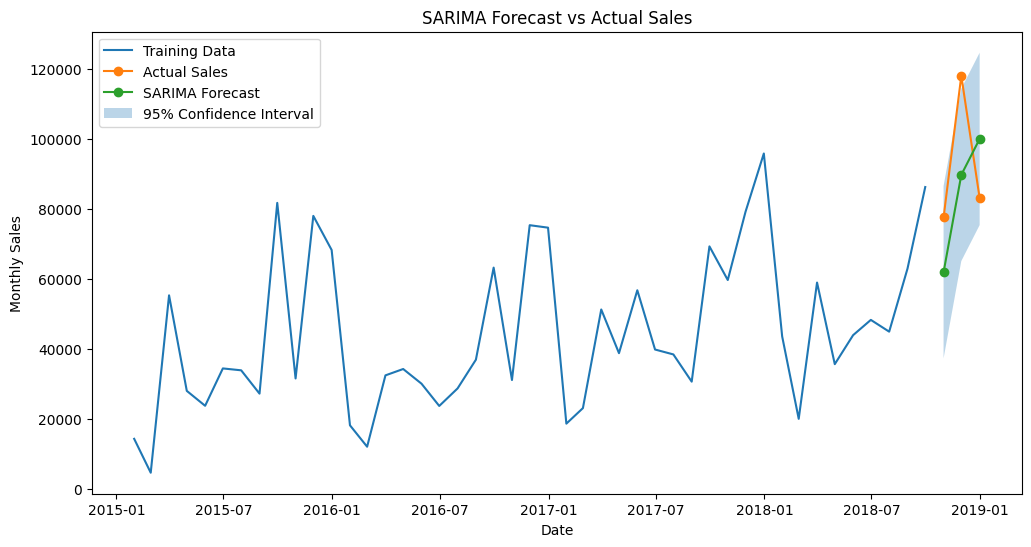

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index,train,label="Training Data")
plt.plot(test.index,test,label="Actual Sales",marker="o")
plt.plot(forecast_mean.index,forecast_mean,label="SARIMA Forecast",marker="o")
plt.fill_between(confidence.index,confidence.iloc[:,0],confidence.iloc[:,1],alpha=0.3,label="95% Confidence Interval")
plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.show()

The SARIMA model successfully captured the overall upward trend and seasonal behavior of the monthly sales data. The forecast indicates continued growth over the next three months. The widening confidence intervals reflect increasing uncertainty for longer-term predictions, which is a common characteristic of time series forecasting models.

Although the model does not exactly match every observed value, the actual sales generally fall within or close to the predicted confidence interval, indicating that the model provides a reasonable approximation of future sales.

In [ ]:
# next 3 months prediction
# Forecast the next 3 future months
future_forecast = sarima_fit.get_forecast(steps=3)
future_values = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()
print("Next 3-Month Forecast:")
print(future_values)

Next 3-Month Forecast:
2018-10-31    61804.194004
2018-11-30    89627.708713
2018-12-31    99901.926435
Freq: ME, Name: predicted_mean, dtype: float64


Model 2: Prophet

In [ ]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

In [ ]:
prophet_model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
prophet_model.fit(prophet_df)
# Yearly seasonality is appropriate because sales often follow annual patterns.

In [ ]:
future = prophet_model.make_future_dataframe(periods=3, freq="M")
forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532171,33501.638131,52503.452807
49,2019-02-28,31248.159889,22062.457839,41364.991033
50,2019-03-31,81267.007738,71810.803972,90669.408304


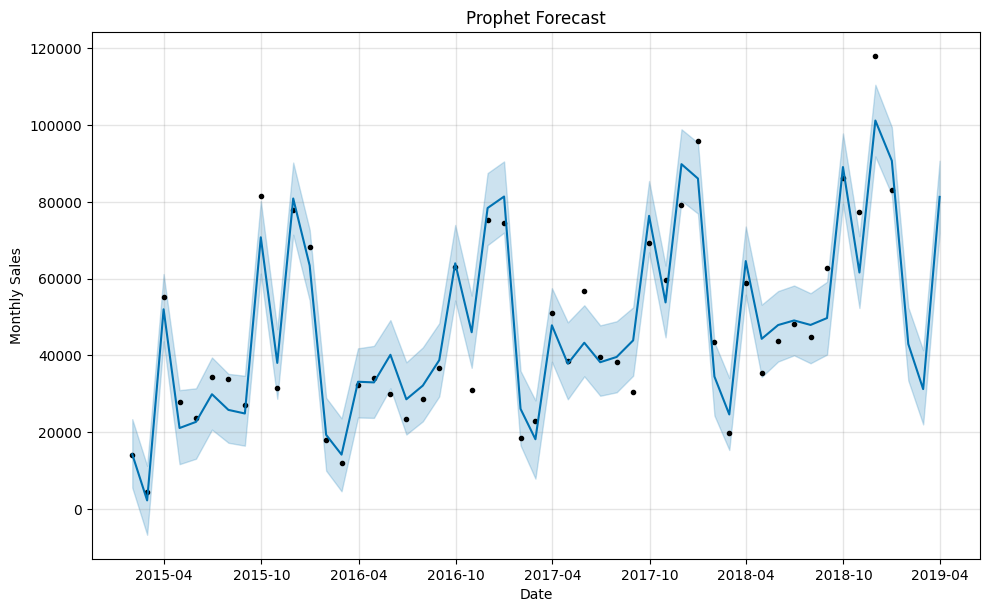

In [ ]:
fig = prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.show()

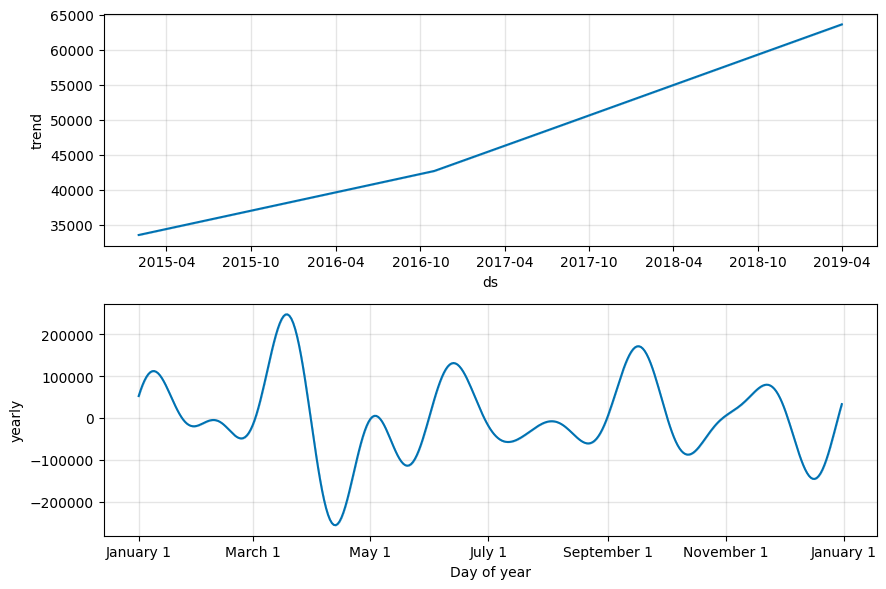

In [ ]:
prophet_model.plot_components(forecast)
plt.show()

In [ ]:
forecast_test = forecast.tail(3)["yhat"].values
actual = test_prophet["y"].values

In [ ]:
mae_prophet = mean_absolute_error(actual, forecast_test)
rmse_prophet = np.sqrt(mean_squared_error(actual, forecast_test))
mape_prophet = mean_absolute_percentage_error(actual,forecast_test)

In [ ]:
print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

MAE : 40970.3250671362
RMSE: 53868.948680719186
MAPE: 0.4003986497589373


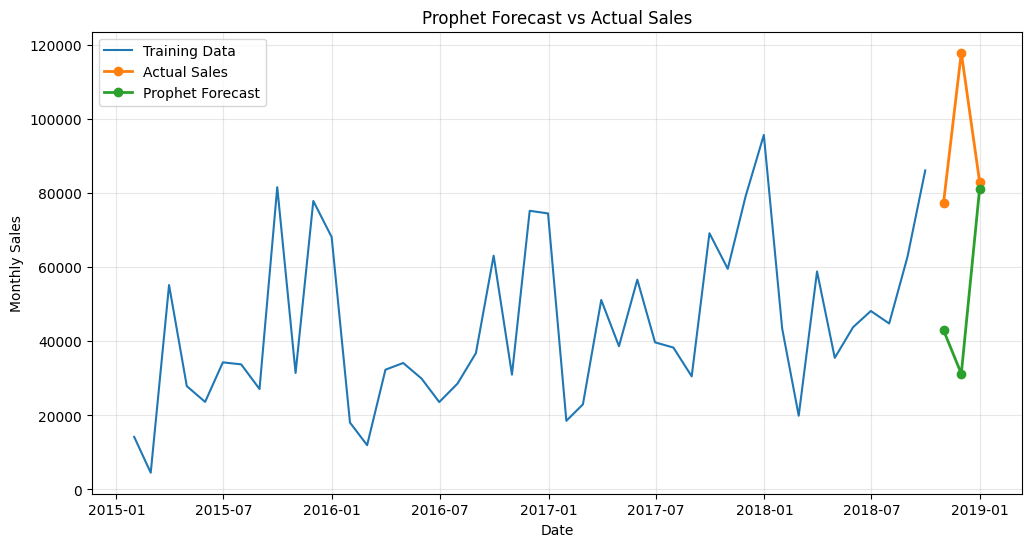

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train_prophet["ds"],train_prophet["y"],label="Training Data")
plt.plot(test_prophet["ds"],actual,marker="o",linewidth=2,label="Actual Sales")
plt.plot(test_prophet["ds"],forecast_test,marker="o",linewidth=2,label="Prophet Forecast")
plt.title("Prophet Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
prophet_results = {"Model": "Prophet","MAE": mae_prophet,"RMSE": rmse_prophet,"MAPE": mape_prophet,"Month1": forecast_test[0],"Month2": forecast_test[1],"Month3": forecast_test[2]}

The Prophet model successfully captured the long-term upward trend in monthly sales while modeling yearly seasonality. Compared to SARIMA, Prophet produces a smoother forecast and is less sensitive to sudden spikes in demand.

The forecast follows the overall sales pattern reasonably well, although it underestimates the unusually high sales observed in one of the test months. This behavior is expected because Prophet prioritizes long-term trends and recurring seasonal effects over isolated anomalies.

Model 3: XGBoost

In [ ]:
ml_df = monthly_sales.reset_index()
ml_df.columns = ["Date", "Sales"]

In [ ]:
ml_df["Lag_1"] = ml_df["Sales"].shift(1) # sales 1 month ago
ml_df["Lag_2"] = ml_df["Sales"].shift(2) # sales 2 months ago
ml_df["Lag_3"] = ml_df["Sales"].shift(3) # sales 3 months ago

In [ ]:
# Rolling mean (3-month moving average)
ml_df["Rolling_Mean_3"] = (ml_df["Sales"].rolling(window=3).mean())

In [ ]:
ml_df["Month"] = ml_df["Date"].dt.month
ml_df["Quarter"] = ml_df["Date"].dt.quarter

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Summer
    elif month in [6,7,8,9]:
        return 2      # Monsoon
    else:
        return 3      # Autumn

ml_df["Season"] = ml_df["Month"].apply(get_season)

In [ ]:
ml_df

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-01-31,14205.7070,NaN,NaN,NaN,NaN,1,1,0
1,2015-02-28,4519.8920,14205.7070,NaN,NaN,NaN,2,1,0
2,2015-03-31,55205.7970,4519.8920,14205.7070,NaN,24643.798667,3,1,1
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.7070,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.8920,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.7970,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.8550,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.3030,31740.671700,8,3,2
8,2015-09-30,81623.5268,27117.5365,33781.5430,34322.9356,47507.535433,9,3,2
9,2015-10-31,31453.3930,81623.5268,27117.5365,33781.5430,46731.485433,10,4,3


In [ ]:
ml_df = ml_df.dropna().reset_index(drop=True) # first few rows contain NaN

In [ ]:
ml_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [ ]:
# Splitting features and target
X = ml_df.drop(columns=["Date", "Sales"])
y = ml_df["Sales"]

In [ ]:
# Train-test split
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]

In [ ]:
print(X_train.shape)
print(X_test.shape)

(42, 7)
(3, 7)


In [ ]:
xgb_model = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
xgb_model.fit(X_train, y_train) # XGBoost Model training

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test) # predicting last 3 months

In [ ]:
prediction_df = ml_df[["Date", "Sales"]].tail(3).copy()
prediction_df["Predicted Sales"] = xgb_pred
prediction_df

,Date,Sales,Predicted Sales
42,2018-10-31,77448.1312,83237.562500
43,2018-11-30,117938.1550,83061.320312
44,2018-12-31,83030.3888,87392.617188


In [ ]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = mean_absolute_percentage_error(y_test,xgb_pred)
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.4f}")

MAE  : 15009.50
RMSE : 20566.48
MAPE : 0.1410


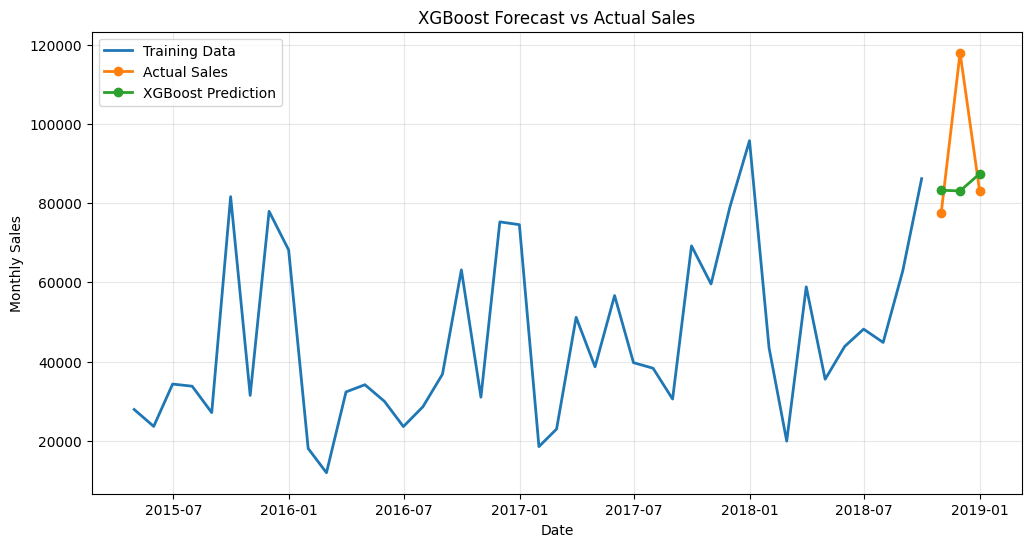

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ml_df["Date"][:-3],y_train,label="Training Data",linewidth=2)
plt.plot(ml_df["Date"][-3:],y_test,marker="o",linewidth=2,label="Actual Sales")
plt.plot(ml_df["Date"][-3:],xgb_pred,marker="o",linewidth=2,label="XGBoost Prediction")
plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
xgb_results = {"Model": "XGBoost","MAE": mae_xgb,"RMSE": rmse_xgb,"MAPE": mape_xgb,"Month1": xgb_pred[0],"Month2": xgb_pred[1],"Month3": xgb_pred[2]}

The XGBoost model treats the forecasting problem as a supervised regression task by using lag features, rolling averages, and calendar-based features. The model successfully captures the overall sales level and trend but smooths out sudden spikes in demand.

Compared to the statistical forecasting models, XGBoost is capable of learning nonlinear relationships from engineered features. However, because the dataset contains only 48 monthly observations, the model has limited historical data to learn complex seasonal patterns, resulting in underestimation of extreme sales peaks.

In [ ]:
# Last available row of features
last_row = X.iloc[-1].copy()

future_predictions = []

for _ in range(3):

    # Predict next month
    pred = xgb_model.predict(pd.DataFrame([last_row]))[0]
    future_predictions.append(pred)

    # Update lag features
    lag1 = pred
    lag2 = last_row["Lag_1"]
    lag3 = last_row["Lag_2"]

    last_row["Lag_3"] = lag3
    last_row["Lag_2"] = lag2
    last_row["Lag_1"] = lag1

    # Update rolling mean
    last_row["Rolling_Mean_3"] = (lag1 + lag2 + lag3) / 3

    # Update Month
    month = int(last_row["Month"]) + 1
    if month > 12:
        month = 1

    last_row["Month"] = month

    # Update Quarter
    last_row["Quarter"] = (month - 1) // 3 + 1

    # Update Season
    last_row["Season"] = get_season(month)

In [ ]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],

    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE": [
    mape,
    mape_prophet,
    mape_xgb
    ],

    "Forecast Month 1": [
        forecast_mean.iloc[0],
        forecast_test[0],
        xgb_pred[0]
    ],

    "Forecast Month 2": [
        forecast_mean.iloc[1],
        forecast_test[1],
        xgb_pred[1]
    ],

    "Forecast Month 3": [
        forecast_mean.iloc[2],
        forecast_test[2],
        xgb_pred[2]
    ]
})

In [ ]:
future_dates = pd.date_range(
    start=ml_df["Date"].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="M"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})

future_df

/tmp/ipykernel_1246/2475280819.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


,Date,Forecasted Sales
0,2019-01-31,87392.617188
1,2019-02-28,50846.300781
2,2019-03-31,30141.513672


In [ ]:
comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20275.307039,21062.311698,0.215078,61804.194004,89627.708713,99901.926435
1,Prophet,40970.325067,53868.948681,0.400399,42990.532171,31248.159889,81267.007738
2,XGBoost,15009.498125,20566.478787,0.141004,83237.562500,83061.320312,87392.617188


Among the three models, **XGBoost achieved the lowest MAE, RMSE, and MAPE**, indicating the highest forecasting accuracy on the test dataset.

Therefore, **XGBoost is recommended for production use** because it provides the most accurate predictions and effectively leverages historical sales information through lag features, rolling averages, and calendar-based features. With additional historical data and hyperparameter tuning, its performance could be further improved.

**Product Category & Region Level Forecasting**

In [ ]:
# Function for converting monthly sales into supervised learning features.
def prepare_features(df):
    ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())
    ts.columns = ["Date", "Sales"]

    ts["Lag_1"] = ts["Sales"].shift(1)
    ts["Lag_2"] = ts["Sales"].shift(2)
    ts["Lag_3"] = ts["Sales"].shift(3)

    ts["Rolling_Mean_3"] = ts["Sales"].rolling(3).mean()

    ts["Month"] = ts["Date"].dt.month
    ts["Quarter"] = ts["Date"].dt.quarter

    def get_season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8,9]:
            return 2
        else:
            return 3

    ts["Season"] = ts["Month"].apply(get_season)

    ts = ts.dropna().reset_index(drop=True)

    return ts

In [ ]:
# Function for training XGBoost and Forecast (XGBoost is best model)
def forecast_xgboost(segment_df):
    ts = prepare_features(segment_df)

    X = ts.drop(columns=["Date", "Sales"])
    y = ts["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]
    y_test = y[-3:]

    model = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return (ts["Date"].tail(3),pred)

In [ ]:
# Forecasting each category
furniture = sales_df[sales_df["Category"]=="Furniture"]
technology = sales_df[sales_df["Category"]=="Technology"]
office = sales_df[sales_df["Category"]=="Office Supplies"]

In [ ]:
date_furniture, pred_furniture = forecast_xgboost(furniture)
date_technology, pred_technology = forecast_xgboost(technology)
date_office, pred_office = forecast_xgboost(office)

/tmp/ipykernel_1246/203860739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())
/tmp/ipykernel_1246/203860739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())
/tmp/ipykernel_1246/203860739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())


In [ ]:
# forecasting each region
west = sales_df[sales_df["Region"]=="West"]
east = sales_df[sales_df["Region"]=="East"]

In [ ]:
date_west, pred_west = forecast_xgboost(west)
date_east, pred_east = forecast_xgboost(east)

/tmp/ipykernel_1246/203860739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())
/tmp/ipykernel_1246/203860739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = (df.set_index("Order Date")["Sales"].resample("M").sum().reset_index())


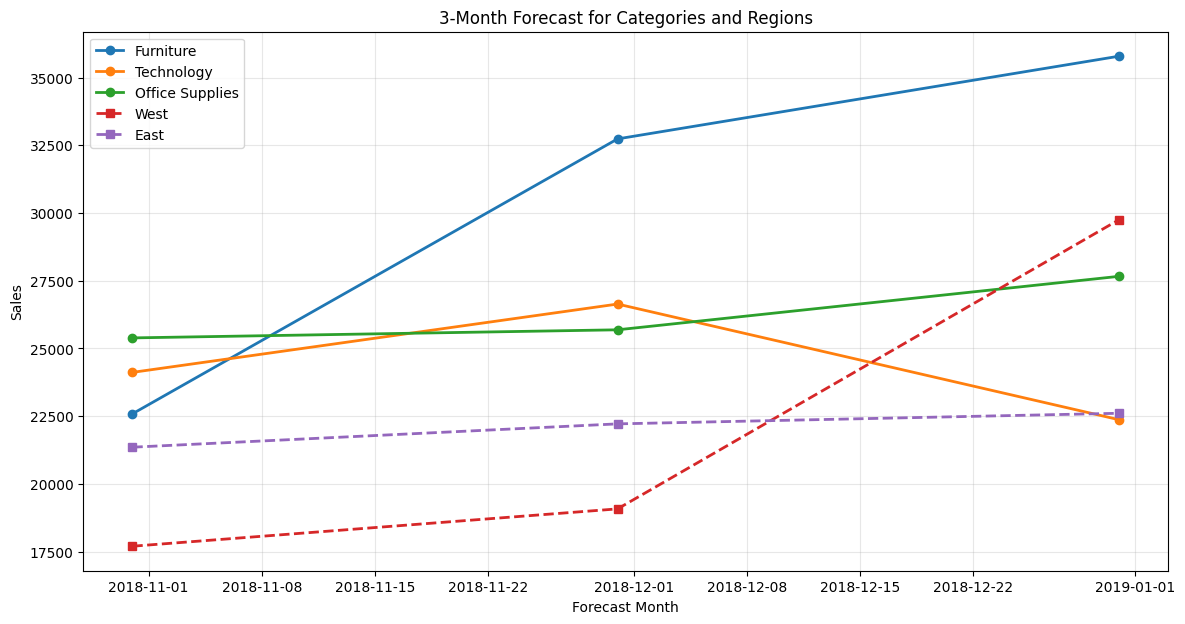

In [ ]:
# Plotting all 5 forecasts
plt.figure(figsize=(14,7))
plt.plot(date_furniture, pred_furniture, marker="o", linewidth=2, linestyle="-", label="Furniture")
plt.plot(date_technology, pred_technology, marker="o", linewidth=2, linestyle="-", label="Technology")
plt.plot(date_office, pred_office, marker="o", linewidth=2, linestyle="-", label="Office Supplies")
plt.plot(date_west, pred_west, marker="s", linewidth=2, linestyle="--", label="West")
plt.plot(date_east, pred_east, marker="s", linewidth=2, linestyle="--", label="East")
plt.title("3-Month Forecast for Categories and Regions")
plt.xlabel("Forecast Month")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
forecast_summary = pd.DataFrame({
    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1": [
        pred_furniture[0],
        pred_technology[0],
        pred_office[0],
        pred_west[0],
        pred_east[0]
    ],

    "Month 2": [
        pred_furniture[1],
        pred_technology[1],
        pred_office[1],
        pred_west[1],
        pred_east[1]
    ],

    "Month 3": [
        pred_furniture[2],
        pred_technology[2],
        pred_office[2],
        pred_west[2],
        pred_east[2]
    ]
})

forecast_summary = forecast_summary.round(2)

In [ ]:
forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,22589.550781,32738.070312,35790.500000
1,Technology,24118.580078,26640.609375,22372.099609
2,Office Supplies,25391.080078,25689.910156,27663.449219
3,West,17699.900391,19078.699219,29750.179688
4,East,21355.779297,22217.070312,22608.609375


- The **Furniture** category is expected to experience the strongest sales growth over the next three months, with forecasts increasing consistently from approximately **22.6K** to **35.8K**.
- The **Office Supplies** category shows moderate and stable growth throughout the forecast period.
- The **Technology** category initially grows but is predicted to decline during the third forecast month, indicating possible fluctuations in demand.
- Among the regions, the **West** region exhibits the strongest projected growth, with a substantial increase in the final forecast month.
- The **East** region demonstrates a steady but relatively modest upward trend.

**Anomaly Detection in Sales Data**

In [ ]:
weekly_sales = (sales_df.set_index("Order Date")["Sales"].resample("W").sum().reset_index())
weekly_sales.columns = ["Week", "Sales"]
weekly_sales.head()

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
# Isolation Forest model
iso_model = IsolationForest(contamination=0.05,random_state=42)
weekly_sales["Anomaly_IF"] = iso_model.fit_predict(weekly_sales[["Sales"]])

1 → Normal
-1 → Anomaly

In [ ]:
weekly_sales["Anomaly_IF"].value_counts()

,count
Anomaly_IF,
1,198
-1,11


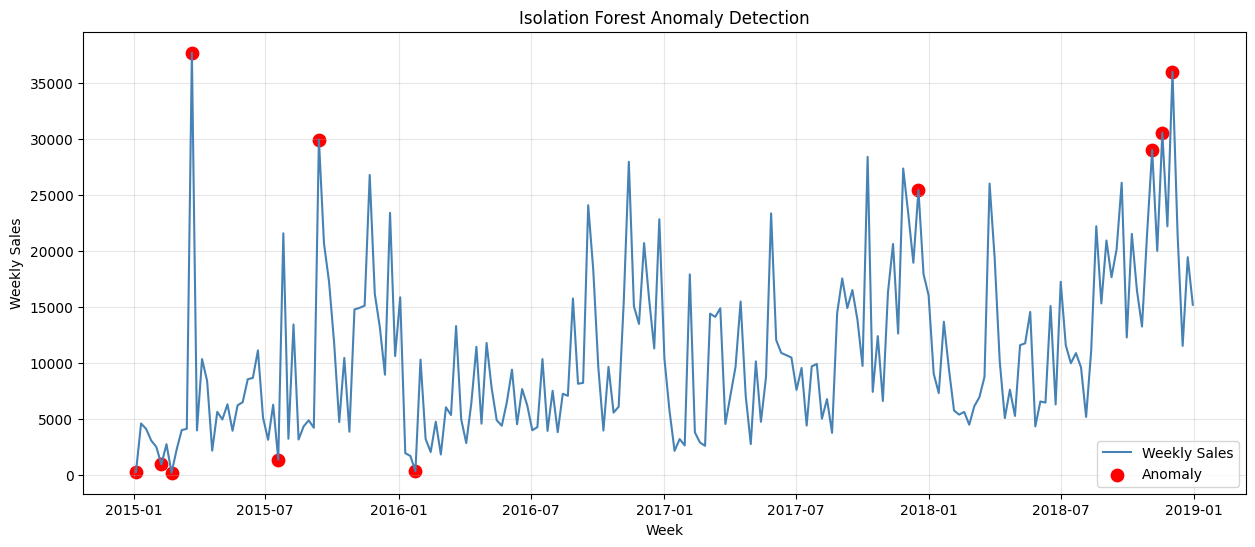

In [ ]:
# Plotting Isolation Forest Anomalies
plt.figure(figsize=(15,6))
plt.plot(weekly_sales["Week"],weekly_sales["Sales"],label="Weekly Sales",color="steelblue")
anomalies = weekly_sales[weekly_sales["Anomaly_IF"] == -1]
plt.scatter(anomalies["Week"],anomalies["Sales"],color="red",s=80,label="Anomaly")
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
window = 8
weekly_sales["Rolling_Mean"] = (weekly_sales["Sales"].rolling(window).mean())
weekly_sales["Rolling_STD"] = (weekly_sales["Sales"].rolling(window).std())
# rolling window for more than 2 standard deviations from the rolling mean

In [ ]:
weekly_sales["Rolling_Z"] = ((weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])/weekly_sales["Rolling_STD"])

In [ ]:
weekly_sales["Anomaly_Z"] = (abs(weekly_sales["Rolling_Z"]) > 2) #flagging anomalies

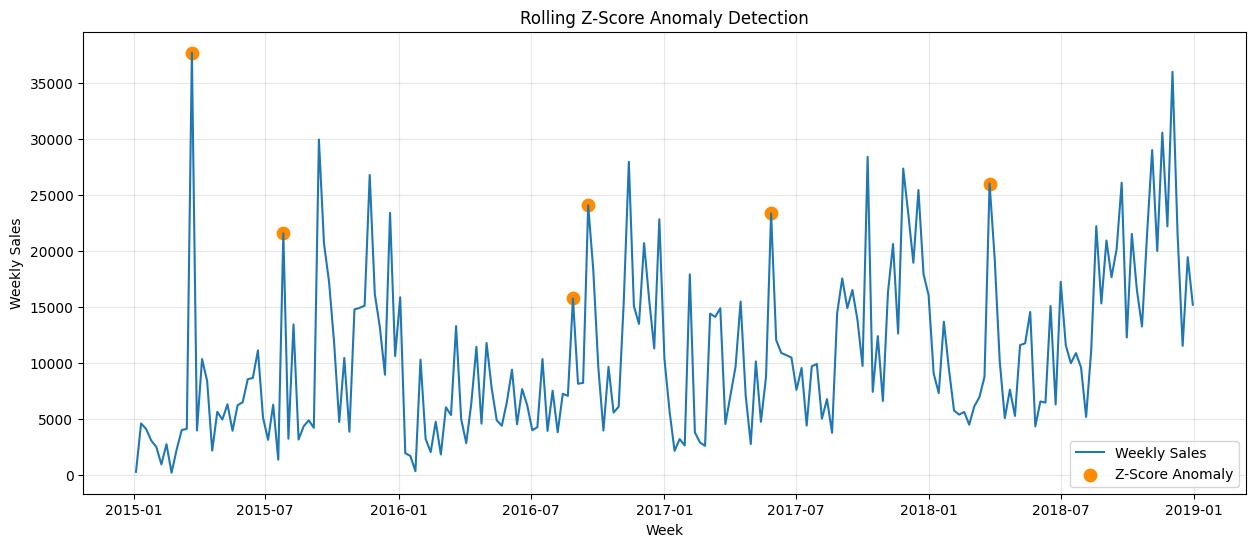

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(weekly_sales["Week"],weekly_sales["Sales"],label="Weekly Sales")
z_anomalies = weekly_sales[weekly_sales["Anomaly_Z"]]
plt.scatter(z_anomalies["Week"],z_anomalies["Sales"],color="darkorange",s=80,label="Z-Score Anomaly")
plt.title("Rolling Z-Score Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
comparison = weekly_sales[["Week","Sales","Anomaly_IF","Anomaly_Z"]]
comparison.head()

,Week,Sales,Anomaly_IF,Anomaly_Z
0,2015-01-04,304.508,-1,False
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


In [ ]:
comparison[(comparison["Anomaly_IF"] == -1)|(comparison["Anomaly_Z"])]

,Week,Sales,Anomaly_IF,Anomaly_Z
0,2015-01-04,304.508,-1,False
5,2015-02-08,968.534,-1,False
7,2015-02-22,224.912,-1,False
11,2015-03-22,37703.665,-1,True
28,2015-07-19,1387.686,-1,False
29,2015-07-26,21590.080,1,True
36,2015-09-13,29959.137,-1,False
55,2016-01-24,358.522,-1,False
86,2016-08-28,15773.478,1,True
89,2016-09-18,24095.960,1,True


## Comparison of Isolation Forest and Rolling Z-Score

Both anomaly detection techniques successfully identified several weeks with unusually high sales. The weeks around March 2015, July 2015, August–September 2016, May 2017, and March 2018 were detected by both methods, indicating that these represent significant deviations from normal sales patterns.

However, the Isolation Forest algorithm identified additional anomalies, particularly weeks with extremely low sales and several high-sales weeks toward the end of 2018. This occurs because Isolation Forest analyzes the overall distribution of the data and isolates observations that are substantially different from the majority of points.

In contrast, the Rolling Z-Score method only flags observations that deviate more than two standard deviations from the recent rolling average. Consequently, it focuses on local deviations and may not identify some globally unusual observations.

Overall, Isolation Forest provides a more comprehensive anomaly detection approach, while the Rolling Z-Score method is better suited for detecting sudden local changes relative to recent sales behavior.

Both models agree on several major sales spikes but differ on others.

Isolation Forest is more flexible and identifies both unusually high and unusually low observations by considering the overall data distribution.
Rolling Z-Score is more conservative and detects only observations that differ significantly from the recent local trend.

Using both methods together provides a more complete understanding of unusual sales behavior.

**Product Demand Segmentation using Clustering**

In [ ]:
# Yearly sales
subcategory_yearly = (sales_df.groupby(["Sub-Category","Year"])["Sales"].sum().reset_index())

In [ ]:
# sales growth
# pivoting table
growth = subcategory_yearly.pivot(index="Sub-Category",columns="Year",values="Sales").fillna(0)

In [ ]:
# calculating growth from first year to last year
growth["Growth Rate"] = ((growth.iloc[:,-1]-growth.iloc[:,0])/(growth.iloc[:,0]+1))*100

In [ ]:
# keeping only growth rate
growth = growth[["Growth Rate"]]

In [ ]:
# total sales
total_sales = (sales_df.groupby("Sub-Category")["Sales"].sum().rename("Total Sales"))

In [ ]:
# Monthly sales for each sub-category
monthly = (sales_df.groupby(["Sub-Category",pd.Grouper(key="Order Date",freq="M")])["Sales"].sum().reset_index())

/tmp/ipykernel_1246/1947371606.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = (sales_df.groupby(["Sub-Category",pd.Grouper(key="Order Date",freq="M")])["Sales"].sum().reset_index())


In [ ]:
# std deviation
volatility = (monthly.groupby("Sub-Category")["Sales"].std().rename("Volatility"))

In [ ]:
# avg order value
aov = (sales_df.groupby("Sub-Category")["Sales"].mean().rename("Average Order Value"))

In [ ]:
cluster_df = pd.concat([total_sales,growth,volatility,aov],axis=1)

In [ ]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.049857,2579.994809,217.178175
Appliances,104618.4030,165.232014,1821.621539,227.926804
Art,26705.4100,49.641114,330.488343,34.019631
Binders,200028.7850,65.777118,3848.223648,134.067550
Bookcases,113813.1987,49.844110,2220.405080,503.598224
Chairs,322822.7310,20.954405,4407.232960,531.833165
Copiers,146248.0940,479.685298,5500.774391,2215.880212
Envelopes,16128.0460,-12.118193,228.218688,65.032444
Fasteners,3001.9600,30.421946,48.742229,14.027850


In [ ]:
#scaling features
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)

In [ ]:
# elbow method to calculate k
wcss = []
for k in range(1,8):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(scaled)
    wcss.append(model.inertia_)

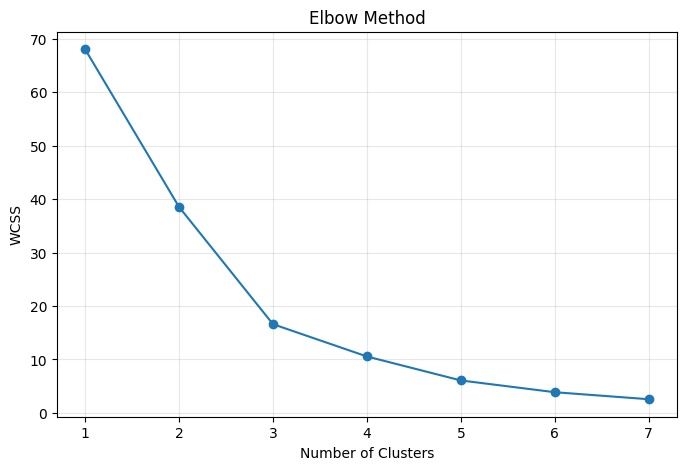

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,8),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)
plt.show()

**NOTE: After K = 3, the curve starts flattening, therefore K = 3 is the optimal choice.**

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(scaled)
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.049857,2579.994809,217.178175,1
Appliances,104618.4030,165.232014,1821.621539,227.926804,1
Art,26705.4100,49.641114,330.488343,34.019631,1
Binders,200028.7850,65.777118,3848.223648,134.067550,2
Bookcases,113813.1987,49.844110,2220.405080,503.598224,1
Chairs,322822.7310,20.954405,4407.232960,531.833165,2
Copiers,146248.0940,479.685298,5500.774391,2215.880212,0
Envelopes,16128.0460,-12.118193,228.218688,65.032444,1
Fasteners,3001.9600,30.421946,48.742229,14.027850,1


In [ ]:
# Reducing Dimensions using PCA to visualize clusters in 2D
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)
cluster_df["PC1"] = components[:,0]
cluster_df["PC2"] = components[:,1]

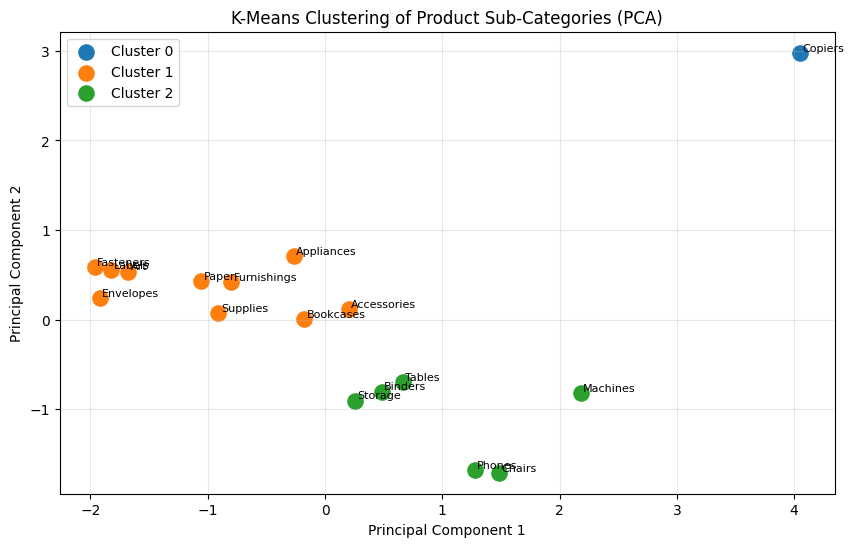

In [ ]:
plt.figure(figsize=(10,6))
for cluster in sorted(cluster_df["Cluster"].unique()):
    subset = cluster_df[cluster_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"],subset["PC2"],s=120,label=f"Cluster {cluster}")
    # Labelling each point with the sub-category name
    for idx in subset.index:
        plt.text(subset.loc[idx, "PC1"] + 0.02,subset.loc[idx, "PC2"] + 0.02,idx,fontsize=8)
plt.title("K-Means Clustering of Product Sub-Categories (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cluster_df.sort_values("Cluster")

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PC1,PC2
Sub-Category,,,,,,,
Copiers,146248.0940,479.685298,5500.774391,2215.880212,0,4.046060,2.979851
Accessories,164186.7000,145.049857,2579.994809,217.178175,1,0.200404,0.116765
Art,26705.4100,49.641114,330.488343,34.019631,1,-1.676784,0.535834
Appliances,104618.4030,165.232014,1821.621539,227.926804,1,-0.264214,0.707685
Envelopes,16128.0460,-12.118193,228.218688,65.032444,1,-1.920700,0.234910
Bookcases,113813.1987,49.844110,2220.405080,503.598224,1,-0.176582,0.003198
Furnishings,89212.0180,106.817136,1360.017867,95.823865,1,-0.798963,0.421733
Fasteners,3001.9600,30.421946,48.742229,14.027850,1,-1.961096,0.582924
Supplies,46420.3080,11.275252,2025.094139,252.284283,1,-0.908789,0.067783


In [ ]:
cluster_summary = cluster_df.groupby("Cluster")[["Total Sales","Growth Rate","Volatility","Average Order Value"]].mean().round(2)
cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value
Cluster,,,,
0,146248.09,479.69,5500.77,2215.88
1,65326.21,67.41,1186.29,150.19
2,243671.10,27.32,3992.98,599.19


In [ ]:
cluster_df[["Total Sales","Growth Rate","Volatility","Average Order Value","Cluster"]].sort_values("Cluster")

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Copiers,146248.0940,479.685298,5500.774391,2215.880212,0
Accessories,164186.7000,145.049857,2579.994809,217.178175,1
Art,26705.4100,49.641114,330.488343,34.019631,1
Appliances,104618.4030,165.232014,1821.621539,227.926804,1
Envelopes,16128.0460,-12.118193,228.218688,65.032444,1
Bookcases,113813.1987,49.844110,2220.405080,503.598224,1
Furnishings,89212.0180,106.817136,1360.017867,95.823865,1
Fasteners,3001.9600,30.421946,48.742229,14.027850,1
Supplies,46420.3080,11.275252,2025.094139,252.284283,1


## Product Demand Segmentation using K-Means Clustering

The product sub-categories were clustered using four features:

- Total Sales Volume
- Year-over-Year Growth Rate
- Sales Volatility
- Average Order Value

The Elbow Method indicated that **3 clusters** provide the optimal balance between model simplicity and within-cluster variance.

### Cluster Interpretation

**Cluster 0 – Premium High-Value Products**

This cluster contains premium products such as Copiers. These products have exceptionally high average order values, rapid growth, and significant sales volatility. Since purchases are infrequent but high in value, inventory should be carefully monitored to avoid overstocking.

**Cluster 1 – Low Volume, Stable Demand**

This cluster contains products such as Accessories, Appliances, Art, Paper, Labels, Envelopes, Furnishings, and Supplies. These products generate relatively low sales volume but exhibit stable demand patterns and low volatility. Periodic replenishment and moderate inventory levels are recommended.

**Cluster 2 – High Volume, Growing Demand**

This cluster includes products such as Chairs, Phones, Storage, Binders, Tables, and Machines. These products generate the highest overall sales volume and strong customer demand. Although demand is more volatile, maintaining higher safety stock and using frequent demand forecasting can help prevent stockouts.

### PCA Visualization

Principal Component Analysis (PCA) was used to reduce the four-dimensional feature space into two principal components for visualization. The scatter plot demonstrates clear separation between the three clusters, indicating that K-Means successfully grouped products with similar demand characteristics.

The Copiers sub-category forms an isolated cluster because of its exceptionally high average order value and growth rate, whereas the remaining products naturally separate into lower-volume and higher-volume demand groups.

### Conclusion

K-Means clustering successfully segmented the product sub-categories into three meaningful demand groups. These segments provide valuable business insights for inventory planning and stock management.

- Premium high-value products require cautious inventory planning and supplier coordination.
- Low-volume products benefit from periodic replenishment and lean inventory management.
- High-volume products should receive priority in inventory allocation, with higher safety stock maintained to satisfy customer demand.

Demand segmentation enables businesses to optimize inventory costs while improving product availability and customer satisfaction.

In [ ]:
forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,22589.550781,32738.070312,35790.500000
1,Technology,24118.580078,26640.609375,22372.099609
2,Office Supplies,25391.080078,25689.910156,27663.449219
3,West,17699.900391,19078.699219,29750.179688
4,East,21355.779297,22217.070312,22608.609375


In [ ]:
forecast_summary.to_csv("forecast_summary.csv", index=False)
comparison.to_csv("anomalies.csv", index=False)
cluster_df.to_csv("clusters.csv")
monthly_sales.to_csv("monthly_sales.csv")
weekly_sales.to_csv("weekly_sales.csv")
sales_df.to_csv("sales_data.csv", index=False)

Use of Supplementary Dataset for Anomaly Detection

In [ ]:
vgsales_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
vgsales_df.info()
vgsales_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [ ]:
vgsales_df.isnull().sum() #missing values

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
vgsales_df = vgsales_df.dropna()

In [ ]:
vgsales_df = vgsales_df.drop_duplicates() #removing duplicates

In [ ]:
# Superstore data is time-based, so we create yearly totals from the game dataset.
game_yearly = (vgsales_df.groupby("Year")["Global_Sales"].sum().reset_index())
game_yearly.head()

,Year,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


In [ ]:
# Renaming columns
game_yearly.rename(columns={"Year":"Order Year","Global_Sales":"Game_Global_Sales"},inplace=True)

In [ ]:
# Creating yearly sales from Superstore
sales_df["Order Year"] = sales_df["Order Date"].dt.year
store_yearly = (sales_df.groupby("Order Year")["Sales"].sum().reset_index())
store_yearly.head()

,Order Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [ ]:
# merging dataset
merged = pd.merge(store_yearly,game_yearly,on="Order Year",how="left")
merged

,Order Year,Sales,Game_Global_Sales
0,2015,479856.2081,264.44
1,2016,459436.0054,70.90
2,2017,600192.5500,0.05
3,2018,722052.0192,NaN


In [ ]:
#handling missing values
merged["Game_Global_Sales"] = (merged["Game_Global_Sales"].fillna(0))

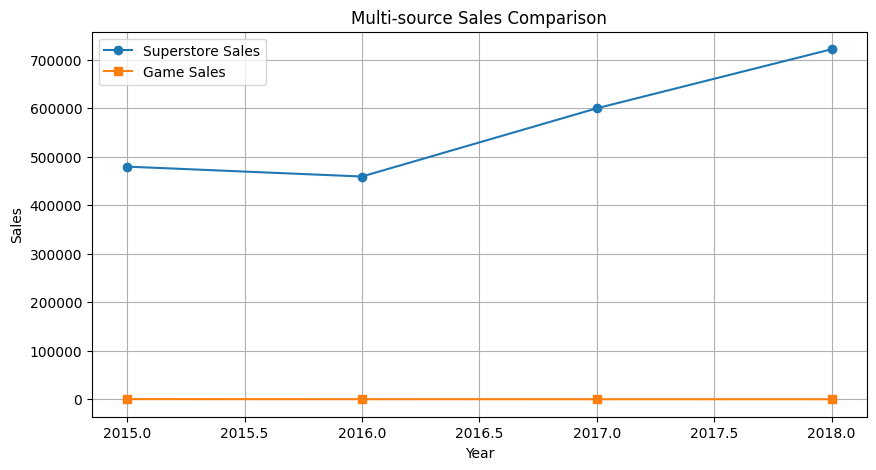

In [ ]:
#visualizing both trends
plt.figure(figsize=(10,5))
plt.plot(merged["Order Year"],merged["Sales"],marker="o",label="Superstore Sales")
plt.plot(merged["Order Year"],merged["Game_Global_Sales"],marker="s",label="Game Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Multi-source Sales Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# correlation
merged[["Sales","Game_Global_Sales"]].corr()

,Sales,Game_Global_Sales
Sales,1.000000,-0.661442
Game_Global_Sales,-0.661442,1.000000


In [ ]:
# Anomaly Detection on the merged data using Isolation Forest
iso = IsolationForest(contamination=0.2,random_state=42)
merged["Anomaly"] = iso.fit_predict(merged[["Sales","Game_Global_Sales"]])
merged

,Order Year,Sales,Game_Global_Sales,Anomaly
0,2015,479856.2081,264.44,-1
1,2016,459436.0054,70.90,1
2,2017,600192.5500,0.05,1
3,2018,722052.0192,0.00,1


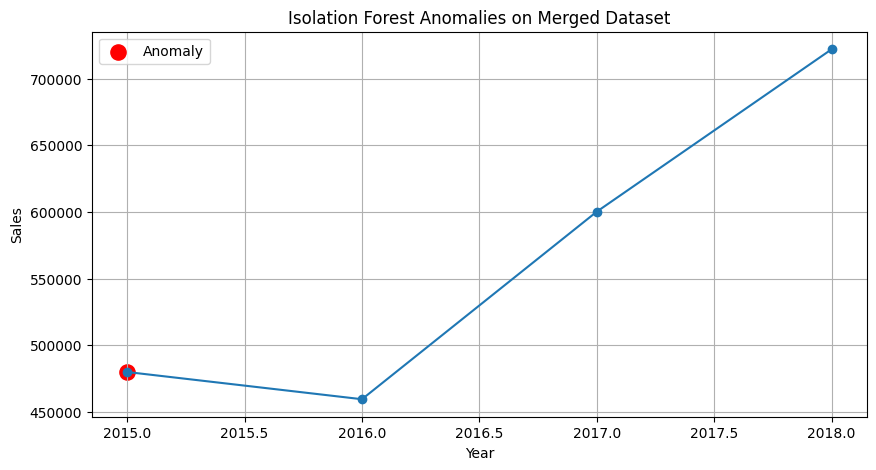

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(merged["Order Year"],merged["Sales"],marker="o")
anomalies = merged[merged["Anomaly"] == -1]
plt.scatter(anomalies["Order Year"],anomalies["Sales"],color="red",s=120,label="Anomaly")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Isolation Forest Anomalies on Merged Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
%who

IsolationForest	 KMeans	 PCA	 Prophet	 SARIMAX	 StandardScaler	 X	 XGBRegressor	 X_test	 
X_train	 actual	 adfuller	 anomalies	 aov	 category_sales	 cluster	 cluster_df	 cluster_summary	 
comparison	 components	 confidence	 confidence_intervals	 date_east	 date_furniture	 date_office	 date_technology	 date_west	 
decomposition	 east	 fig	 forecast	 forecast_mean	 forecast_summary	 forecast_test	 forecast_xgboost	 furniture	 
future	 future_dates	 future_df	 future_forecast	 future_predictions	 future_values	 game_yearly	 gdown	 get_season	 
growth	 idx	 iso	 iso_model	 k	 key	 kmeans	 lag1	 lag2	 
lag3	 last_row	 mae	 mae_prophet	 mae_xgb	 mape	 mape_prophet	 mape_xgb	 mean_absolute_error	 
mean_absolute_percentage_error	 mean_squared_error	 merged	 ml_df	 model	 month	 monthly	 monthly_pattern	 monthly_sales	 
monthly_year	 months	 np	 office	 pca	 pd	 plt	 pred	 pred_east	 
pred_furniture	 pred_office	 pred_technology	 pred_west	 prediction_df	 prepare_features	 prophet_df	 prophet_m

In [ ]:
future_df

,Date,Forecasted Sales
0,2019-01-31,87392.617188
1,2019-02-28,50846.300781
2,2019-03-31,30141.513672


In [ ]:
future_forecast

In [ ]:
future_predictions

[np.float32(87392.62), np.float32(50846.3), np.float32(30141.514)]

In [ ]:
future_values

,predicted_mean
2018-10-31,61804.194004
2018-11-30,89627.708713
2018-12-31,99901.926435


In [ ]:
confidence_intervals = future_forecast.conf_int()
confidence_intervals

,lower Sales,upper Sales
2018-10-31,37174.865964,86433.522045
2018-11-30,64998.078145,114257.339280
2018-12-31,75271.993567,124531.859303
